# Explore adata

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import os

In [2]:
adata = sc.read_h5ad("../sclc_raw/5b7cbce2-ed53-47a4-99f8-10af741814e6.h5ad")
adata

AnnData object with n_obs × n_vars = 147137 × 22021
    obs: 'ngenes', 'libsize', 'mito_frac', 'RBP_frac', 'batch', 'donor_id', 'treatment', 'procedure', 'histo', 'cell_type_coarse', 'cell_type_fine', 'cell_type_general', 'clusters', 'cell_type_med', 'H_knn', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'suspension_type', 'HTAN_Biospecimen_ID', 'HTAN_Participant_ID', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_umap'

In [3]:
# Explore cell metadata
print("Columns:", adata.obs.columns.tolist())
display(adata.obs.head())
print("Metadata summary:")
display(adata.obs.describe(include="all"))

# Explore unique values of categorical metadata
categorical_cols = [
    col for col in adata.obs.columns
    if adata.obs[col].dtype == "object"
    or str(adata.obs[col].dtype).startswith("category")
    ]
for col in categorical_cols:
    try:
        print(adata.obs[col].value_counts().head(20))
    except:
        print("Cannot display value counts")

display(pd.crosstab(adata.obs["disease"],adata.obs["cell_type"]))

Columns: ['ngenes', 'libsize', 'mito_frac', 'RBP_frac', 'batch', 'donor_id', 'treatment', 'procedure', 'histo', 'cell_type_coarse', 'cell_type_fine', 'cell_type_general', 'clusters', 'cell_type_med', 'H_knn', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'suspension_type', 'HTAN_Biospecimen_ID', 'HTAN_Participant_ID', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid']


,ngenes,libsize,mito_frac,RBP_frac,batch,donor_id,treatment,procedure,histo,cell_type_coarse,...,HTAN_Participant_ID,tissue_type,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
Cell,,,,,,,,,,,,,,,,,,,,,
RU1311A_T_1_165945547864806,255,2.594393,0.055980,0.315522,RU1311A_T_1,RU1311,Platinum Doublet,Biopsy,SCLC,Lymphoid,...,HTA8_2016,tissue,T cell,10x 3' v3,small cell lung carcinoma,female,lung,unknown,77-year-old stage,q1?ma!F=Xe
RU1215_192110488599350,3720,4.285895,0.060109,0.401657,RU1215,RU1215,Naive,Thoracentesis,SCLC,Epithelial,...,HTA8_2012,tissue,epithelial cell,10x 3' v3,small cell lung carcinoma,female,pleural effusion,unknown,75-year-old stage,M!tK?#Xfph
RU1057_T_231270811326245,2293,3.963505,0.030455,0.363389,RU1057_T,RU1057,Naive,Resection,LUAD,Mesenchymal,...,HTA8_1002,tissue,endothelial cell,10x 3' v2,lung adenocarcinoma,female,lung,unknown,67-year-old stage,wUE_o#x^2C
RU1152_130751366121844,5093,4.374162,0.073601,0.185821,RU1152,RU1152,Naive,Biopsy,SCLC,Epithelial,...,HTA8_2009,tissue,epithelial cell,10x 3' v3,small cell lung carcinoma,male,lymph node,unknown,71-year-old stage,!9F#zgnv3I
RU699_227364270922139,1658,3.729489,0.011559,0.218121,RU699,RU699,"Platinum Doublet,Immunotherapy",Resection,LUAD,Lymphoid,...,HTA8_1021,tissue,T cell,10x 3' v2,lung adenocarcinoma,female,adrenal gland,unknown,44-year-old stage,l6CxDWQf>R


Metadata summary:


,ngenes,libsize,mito_frac,RBP_frac,batch,donor_id,treatment,procedure,histo,cell_type_coarse,...,HTAN_Participant_ID,tissue_type,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
count,147137.000000,147137.000000,147137.000000,147137.000000,147137,147137,147137,147137,147137,147137,...,147137,147137,147137,147137,147137,147137,147137,147137,147137,147137
unique,NaN,NaN,NaN,NaN,52,42,9,3,3,4,...,45,1,11,3,3,2,8,3,26,147137
top,NaN,NaN,NaN,NaN,RU1293A,RU1108,Naive,Resection,SCLC,Epithelial,...,HTA8_2005,tissue,epithelial cell,10x 3' v2,small cell lung carcinoma,female,lung,unknown,74-year-old stage,q1?ma!F=Xe
freq,NaN,NaN,NaN,NaN,6484,11294,66888,86272,77143,64301,...,11294,147137,64302,92035,77143,83259,90384,134630,19763,1
mean,2205.696840,3.721064,0.060367,0.245877,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1580.897688,0.508769,0.043701,0.112980,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,36.000000,2.004321,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1011.000000,3.469380,0.026598,0.163331,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1680.000000,3.752356,0.049331,0.229660,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,3284.000000,4.094611,0.086054,0.319175,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


batch
RU1293A                     6484
RU1231A                     5098
RU1145                      4696
RU661_T                     4434
RU1215                      4420
RU1108a_Bambanker_Frozen    4231
RU1108a_RPMI                4137
RU1065C                     4060
RU682_T                     3931
RU676                       3900
RU1262C                     3857
RU682_N                     3829
RU1229A_Frozen              3811
RU1080C                     3799
RU1066                      3794
RU1134-CN2                  3300
RU1322A_LN                  3275
RU1134_Sort-Freeze          3264
RU1138                      3209
RU675_T                     3196
Name: count, dtype: int64
donor_id
RU1108    11294
RU682      7760
RU1134     6564
RU1293     6484
RU675      6175
RU1170     5679
RU1231     5098
RU1181     4873
RU1145     4696
RU1144     4603
RU661      4434
RU1215     4420
RU1065     4060
RU676      3900
RU1262     3857
RU1229     3811
RU1080     3799
RU1066     3794
RU1322     

cell_type,fibroblast,epithelial cell,T cell,mast cell,endothelial cell,erythrocyte,macrophage,B cell,dendritic cell,neutrophil,plasma cell
disease,,,,,,,,,,,
lung adenocarcinoma,4067,7575,29580,971,2395,46,4866,4846,2346,358,629
small cell lung carcinoma,800,55876,15638,105,593,1,1051,788,1530,726,35
normal,37,851,6630,191,90,0,3334,127,1032,21,2


In [4]:
# Explore gene metadata
print("Columns:", adata.var.columns.tolist())
display(adata.var.head())
print("Metadata summary:")
display(adata.var.describe(include="all"))

Columns: ['feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type']


,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000121410,False,A1BG,NCBITaxon:9606,gene,2301,protein_coding
ENSG00000148584,False,A1CF,NCBITaxon:9606,gene,2211,protein_coding
ENSG00000175899,False,A2M,NCBITaxon:9606,gene,590,protein_coding
ENSG00000166535,False,A2ML1,NCBITaxon:9606,gene,592,protein_coding
ENSG00000128274,False,A4GALT,NCBITaxon:9606,gene,1956,protein_coding


Metadata summary:


,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
count,22021,22021,22021,22021,22021,22021
unique,1,22017,1,1,4672,17
top,False,LINC03021,NCBITaxon:9606,gene,582,protein_coding
freq,22021,2,22021,22021,45,17494


In [6]:
# Explore one cell
cell_id = adata.obs_names[0]
print("Cell ID:", cell_id)
display(adata.obs.loc[cell_id])

expr = adata[cell_id].X
expr = np.array(expr).flatten()
top_idx = np.argsort(expr)[::-1][:20]
top_genes = pd.DataFrame({
    "gene": adata.var_names[top_idx],
    "expression": expr[top_idx]
})
display(top_genes)

Cell ID: RU1311A_T_1_165945547864806


ngenes                                                            255
libsize                                                      2.594393
mito_frac                                                     0.05598
RBP_frac                                                     0.315522
batch                                                     RU1311A_T_1
donor_id                                                       RU1311
treatment                                            Platinum Doublet
procedure                                                      Biopsy
histo                                                            SCLC
cell_type_coarse                                             Lymphoid
cell_type_fine                                                 T cell
cell_type_general                                              Immune
clusters                                                           23
cell_type_med                                                  T cell
H_knn               

,gene,expression
0,ENSG00000121410,<Compressed Sparse Row sparse matrix of dtype ...


# Optimize adata

In [7]:
adata.obsm = {}
adata.uns = {}
adata

AnnData object with n_obs × n_vars = 147137 × 22021
    obs: 'ngenes', 'libsize', 'mito_frac', 'RBP_frac', 'batch', 'donor_id', 'treatment', 'procedure', 'histo', 'cell_type_coarse', 'cell_type_fine', 'cell_type_general', 'clusters', 'cell_type_med', 'H_knn', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'suspension_type', 'HTAN_Biospecimen_ID', 'HTAN_Participant_ID', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'

In [9]:
keep_obs = ["donor_id", "cell_type", "disease", "sex", "development_stage", "tissue"]
adata.obs = adata.obs[keep_obs].copy()
keep_var = ["feature_name"]
adata.var = adata.var[keep_var].copy()

adata.var["ensembl_id"] = adata.var.index.astype(str)
adata.obs["cell_id"] = adata.obs_names
if "n_counts" not in adata.obs.columns:
    adata.obs["n_counts"] = np.asarray(adata.X.sum(axis=1)).ravel()

adata

AnnData object with n_obs × n_vars = 147137 × 22021
    obs: 'donor_id', 'cell_type', 'disease', 'sex', 'development_stage', 'tissue', 'cell_id', 'n_counts'
    var: 'feature_name', 'ensembl_id'

In [ ]:
adata.obs["age"] = (
    adata.obs["development_stage"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

adata.obs["age"] = adata.obs["age"].fillna(
    adata.obs["age"].median()
)

In [16]:
print(adata.obs["donor_id"].unique())
print(adata.obs["tissue"].unique())
print(adata.obs["cell_type"].unique())
print(adata.obs["disease"].unique())
print(adata.obs["sex"].unique())
print(adata.obs["age"].unique())

['RU1311', 'RU1215', 'RU1057', 'RU1152', 'RU699', ..., 'RU1195', 'RU1061', 'RU426', 'RU1271', 'RU653']
Length: 42
Categories (42, object): ['PleuralEffusion', 'RU255', 'RU426', 'RU653', ..., 'RU1271', 'RU1293', 'RU1311', 'RU1322']
['lung', 'pleural effusion', 'lymph node', 'adrenal gland', 'liver', 'axilla', 'brain', 'bone spine']
Categories (8, object): ['lymph node', 'pleural effusion', 'brain', 'lung', 'liver', 'adrenal gland', 'axilla', 'bone spine']
['T cell', 'epithelial cell', 'endothelial cell', 'macrophage', 'dendritic cell', ..., 'mast cell', 'B cell', 'fibroblast', 'neutrophil', 'erythrocyte']
Length: 11
Categories (11, object): ['fibroblast', 'epithelial cell', 'T cell', 'mast cell', ..., 'B cell', 'dendritic cell', 'neutrophil', 'plasma cell']
['small cell lung carcinoma', 'lung adenocarcinoma', 'normal']
Categories (3, object): ['lung adenocarcinoma', 'small cell lung carcinoma', 'normal']
['female', 'male']
Categories (2, object): ['female', 'male']
[77. 75. 67. 71. 44. 

In [14]:
df = adata.obs
result = (
    df.groupby("disease")
      .agg(
          num_cell=("cell_id", "count"),
          num_donor=("donor_id", "nunique")
      )
      .reset_index()
)
result

/tmp/ipykernel_4125006/1534638516.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("disease")


,disease,num_cell,num_donor
0,lung adenocarcinoma,57679,21
1,small cell lung carcinoma,77143,20
2,normal,12315,4


In [33]:
adata.obs["filter_pass"] = 1
keep_obs = ["donor_id", "cell_id", "cell_type", "disease", "sex", "age", "tissue", "n_counts", "filter_pass"]
adata.obs = adata.obs[keep_obs].copy()
adata

AnnData object with n_obs × n_vars = 147137 × 22021
    obs: 'donor_id', 'cell_id', 'cell_type', 'disease', 'sex', 'age', 'tissue', 'n_counts', 'filter_pass'
    var: 'feature_name', 'ensembl_id'

In [34]:
adata_sub = adata[
    (adata.obs["tissue"] == "lung") &
    (adata.obs["cell_type"] == "epithelial cell") &
    (adata.obs["disease"].isin([
        "lung adenocarcinoma",
        "small cell lung carcinoma"
    ]))
].copy()

adata_sub

AnnData object with n_obs × n_vars = 31258 × 22021
    obs: 'donor_id', 'cell_id', 'cell_type', 'disease', 'sex', 'age', 'tissue', 'n_counts', 'filter_pass'
    var: 'feature_name', 'ensembl_id'

In [35]:
df = adata_sub.obs
result = (
    df.groupby("disease")
      .agg(
          num_cell=("cell_id", "count"),
          num_donor=("donor_id", "nunique")
      )
      .reset_index()
)
result

/tmp/ipykernel_4125006/2333948598.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("disease")


,disease,num_cell,num_donor
0,lung adenocarcinoma,5270,16
1,small cell lung carcinoma,25988,9


In [36]:
adata_sub.write_h5ad("input_data/adata_sub.h5ad")

In [44]:
adata_sub3 = adata[
    (adata.obs["tissue"] == "lung") &
    (adata.obs["cell_type"] == "epithelial cell")
].copy()

df = adata_sub3.obs
result = (
    df.groupby("disease")
      .agg(
          num_cell=("cell_id", "count"),
          num_donor=("donor_id", "nunique")
      )
      .reset_index()
)
result

adata_sub3.write_h5ad("input_data3/adata_sub3.h5ad")

/tmp/ipykernel_4125006/1855542349.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("disease")


# Tokenize

In [37]:
adata_sub = sc.read_h5ad("input_data/adata_sub.h5ad")
adata_sub

AnnData object with n_obs × n_vars = 31258 × 22021
    obs: 'donor_id', 'cell_id', 'cell_type', 'disease', 'sex', 'age', 'tissue', 'n_counts', 'filter_pass'
    var: 'feature_name', 'ensembl_id'

In [38]:
custom_attrs = {
    "cell_type": "cell_type",
    "cell_id": "cell_id",
    "disease": "disease",
    "donor_id": "individual",
    "sex": "sex",
    "age": "age"
}

In [39]:
from geneformer import TranscriptomeTokenizer

tk = TranscriptomeTokenizer(
  custom_attr_name_dict=custom_attrs,
  chunk_size=512,
  model_input_size=1024,
  nproc=8,
  model_version="V1"
  )

tk.tokenize_data(
    data_directory="input_data",
    output_directory="output_data",
    output_prefix="cm_tokenized",
    file_format="h5ad"
    )

Tokenizing input_data/adata_sub.h5ad


/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i in adata.var["ensembl_id_collapsed"][coding_miRNA_loc]
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/geneformer/tokenizer.py:547: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coding_miRNA_ids = adata.var["ensembl_id_collapsed"][coding_miRNA_loc]


Creating dataset.


In [40]:
from datasets import load_from_disk
ds = load_from_disk("output_data/cm_tokenized.dataset")
ds

Dataset({
    features: ['input_ids', 'cell_type', 'cell_id', 'disease', 'individual', 'sex', 'age', 'length'],
    num_rows: 31258
})

In [ ]:
ds[0]

In [42]:
len(ds[0]["input_ids"])

2048

In [46]:
adata_sub3 = sc.read_h5ad("input_data3/adata_sub3.h5ad")

tk = TranscriptomeTokenizer(
  custom_attr_name_dict=custom_attrs,
  chunk_size=512,
  model_input_size=1024,
  nproc=8,
  model_version="V1"
  )

tk.tokenize_data(
    data_directory="input_data3",
    output_directory="output_data3",
    output_prefix="cm_tokenized3",
    file_format="h5ad"
    )

ds = load_from_disk("output_data3/cm_tokenized3.dataset")
ds

Tokenizing input_data3/adata_sub3.h5ad


/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i in adata.var["ensembl_id_collapsed"][coding_miRNA_loc]
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/geneformer/tokenizer.py:547: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coding_miRNA_ids = adata.var["ensembl_id_collapsed"][coding_miRNA_loc]


Creating dataset.


Dataset({
    features: ['input_ids', 'cell_type', 'cell_id', 'disease', 'individual', 'sex', 'age', 'length'],
    num_rows: 32109
})

# Classification 2

In [50]:
donor_df = (
    adata_sub.obs[["donor_id", "disease"]]
    .drop_duplicates()
    .sort_values("donor_id")
)

print(donor_df)

                                   donor_id                    disease
Cell                                                                  
RU426B_227303182691099                RU426  small cell lung carcinoma
RU653_T_164761064589214               RU653        lung adenocarcinoma
RU661_T_160440071437027               RU661        lung adenocarcinoma
RU675_T_134592140529052               RU675        lung adenocarcinoma
RU676_169151714257187                 RU676        lung adenocarcinoma
RU682_T_126132113828764               RU682        lung adenocarcinoma
RU684_T_155971398822774               RU684        lung adenocarcinoma
RU1038_Sort-Freeze_120786785593067   RU1038        lung adenocarcinoma
RU1057_T_165851864165284             RU1057        lung adenocarcinoma
RU1061_157486628584347               RU1061        lung adenocarcinoma
RU1066_195967073508188               RU1066  small cell lung carcinoma
RU1108a_RPMI_164761076713396         RU1108  small cell lung carcinoma
RU1128

In [54]:
from sklearn.model_selection import train_test_split

train_eval_df, test_df = train_test_split(
    donor_df,
    test_size=0.20,
    stratify=donor_df["disease"],
    random_state=42
)

train_df, eval_df = train_test_split(
    train_eval_df,
    test_size=0.20,
    stratify=train_eval_df["disease"],
    random_state=42
)

train_ids = train_df["donor_id"].tolist()
eval_ids = eval_df["donor_id"].tolist()
test_ids = test_df["donor_id"].tolist()

print("train:", train_ids)
print("eval:", eval_ids)
print("test:", test_ids)

train: ['RU1057', 'RU1311', 'RU1229', 'RU1262', 'RU1195', 'RU1135', 'RU661', 'RU1181', 'RU1128', 'RU653', 'RU675', 'RU426', 'RU1271', 'RU1170', 'RU1144', 'RU1061']
eval: ['RU684', 'RU1108', 'RU1134', 'RU682']
test: ['RU1145', 'RU1038', 'RU676', 'RU1137', 'RU1066']


In [56]:
from geneformer import Classifier

training_args = {
    "num_train_epochs": 1,
    "learning_rate": 1e-4,
    "per_device_train_batch_size": 12,
    "seed": 42,
}

cc = Classifier(
    classifier="cell",
    cell_state_dict={
        "state_key": "disease",
        "states": "all"
    },
    filter_data=None,
    training_args=training_args,
    max_ncells=None,
    freeze_layers=3,
    num_crossval_splits=1,
    forward_batch_size=32,
    nproc=4,
    model_version="V1"
)

In [57]:
train_test_id_split_dict = {
    "attr_key": "individual",
    "train": train_ids + eval_ids,
    "test": test_ids,
}

train_valid_id_split_dict = {
    "attr_key": "individual",
    "train": train_ids,
    "eval": eval_ids,
}

cc.prepare_data(
    input_data_file="output_data/cm_tokenized.dataset",
    output_directory="finetuned_model",
    output_prefix="cm_dz_classifier",
    split_id_dict=train_test_id_split_dict
)

In [59]:
os.environ["WANDB_DISABLED"] = "true"

all_metrics = cc.validate(
    model_directory="../Geneformer-V1-10M",
    prepared_input_data_file="finetuned_model/cm_dz_classifier_labeled_train.dataset",
    id_class_dict_file="finetuned_model/cm_dz_classifier_id_class_dict.pkl",
    output_directory="finetuned_model",
    output_prefix="cm_dz_classifier",
    attr_to_split="individual",
    attr_to_balance=["disease", "age", "sex"],
    n_hyperopt_trials=0
)

  0%|                                                     | 0/1 [00:00<?, ?it/s]

****** Validation split: 1/1 ******



/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/scipy/stats/_stats_py.py:7192: RuntimeWarning: divide by zero encountered in divide
  terms = (f_obs - f_exp)**2 / f_exp
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/scipy/stats/_stats_py.py:7192: RuntimeWarning: divide by zero encountered in divide
  terms = (f_obs - f_exp)**2 / f_exp
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/scipy/stats/_stats_py.py:7192: RuntimeWarning: divide by zero encountered in divide
  terms = (f_obs - f_exp)**2 / f_exp
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ../Geneformer-V1-10M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/petadimensionlab/workspace/Ge

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.039500,0.221380,0.951282,0.940971



100%|████████████████████████████████████████████| 1/1 [09:15<00:00, 555.22s/it]


In [61]:
all_metrics_test = cc.evaluate_saved_model(
    model_directory="finetuned_model/260611_geneformer_cellClassifier_cm_dz_classifier/ksplit1/",
    id_class_dict_file="finetuned_model/cm_dz_classifier_id_class_dict.pkl",
    test_data_file="finetuned_model/cm_dz_classifier_labeled_test.dataset",
    output_directory="finetuned_model",
    output_prefix="cm_dz_classifier"
)

100%|█████████████████████████████████████████| 205/205 [01:44<00:00,  1.95it/s]


<Figure size 1000x1000 with 0 Axes>

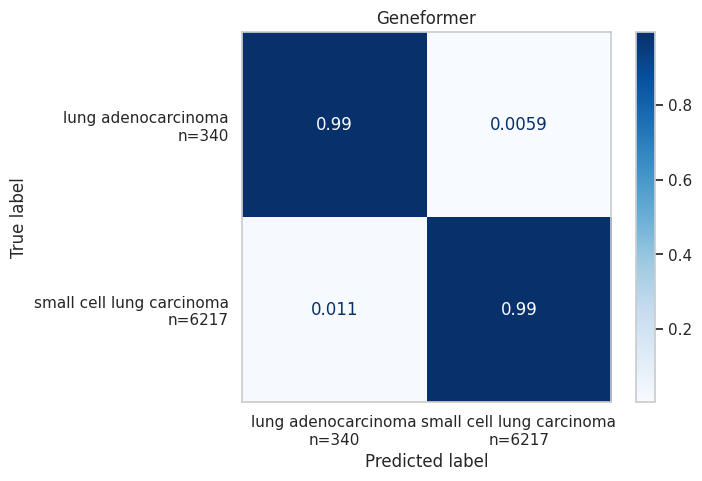

In [62]:
cc.plot_conf_mat(
    conf_mat_dict={"Geneformer": all_metrics_test["conf_matrix"]},
    output_directory="finetuned_model",
    output_prefix="cm_dz_classifier",
    custom_class_order=["lung adenocarcinoma", "small cell lung carcinoma"]
)

<Figure size 1500x1500 with 0 Axes>

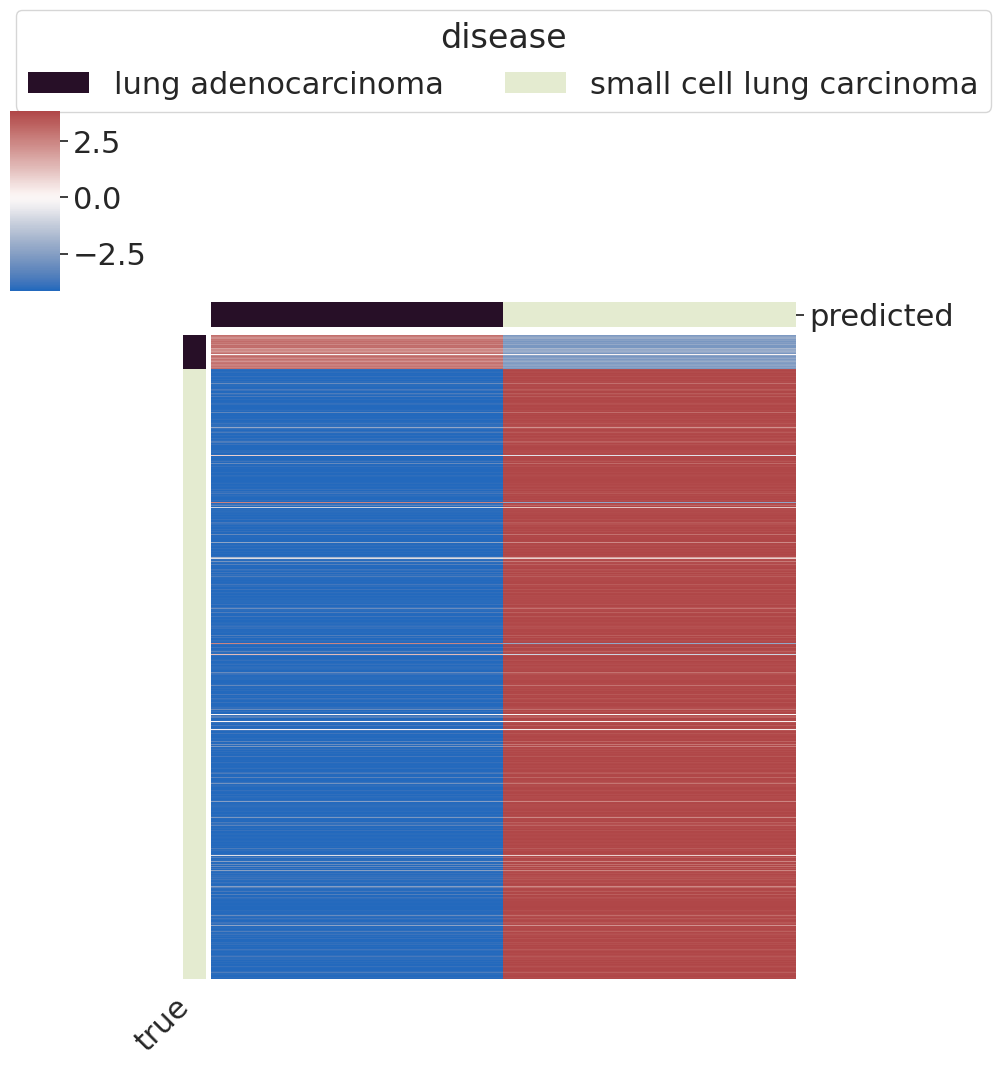

In [63]:
cc.plot_predictions(
    predictions_file="finetuned_model/cm_dz_classifier_pred_dict.pkl",
    id_class_dict_file="finetuned_model/cm_dz_classifier_id_class_dict.pkl",
    title="disease",
    output_directory="finetuned_model",
    output_prefix="cm_dz_classifier",
    custom_class_order=["lung adenocarcinoma", "small cell lung carcinoma"]
)

# Classification 3

In [84]:
donor_df3 = (
    adata_sub3.obs[["donor_id", "disease"]]
    .drop_duplicates()
    .sort_values("donor_id")
)

print(donor_df3)

                                   donor_id                    disease
Cell                                                                  
RU426B_227303182691099                RU426  small cell lung carcinoma
RU653_T_164761064589214               RU653        lung adenocarcinoma
RU661_T_160440071437027               RU661        lung adenocarcinoma
RU675_N_204213425723118               RU675                     normal
RU675_T_134592140529052               RU675        lung adenocarcinoma
RU676_169151714257187                 RU676        lung adenocarcinoma
RU682_T_126132113828764               RU682        lung adenocarcinoma
RU682_N_169158873934260               RU682                     normal
RU684_T_155971398822774               RU684        lung adenocarcinoma
RU684_N_126776270798243               RU684                     normal
RU685_N_226883234392347               RU685                     normal
RU1038_Sort-Freeze_120786785593067   RU1038        lung adenocarcinoma
RU1057

In [85]:
from sklearn.model_selection import train_test_split

train_eval_df, test_df = train_test_split(
    donor_df3,
    test_size=0.20,
    stratify=donor_df3["disease"],
    random_state=42
)

train_df, eval_df = train_test_split(
    train_eval_df,
    test_size=0.20,
    stratify=train_eval_df["disease"],
    random_state=42
)

train_ids = train_df["donor_id"].tolist()
eval_ids = eval_df["donor_id"].tolist()
test_ids = test_df["donor_id"].tolist()

print("train:", train_ids)
print("eval:", eval_ids)
print("test:", test_ids)

train: ['RU1262', 'RU1311', 'RU1134', 'RU1145', 'RU685', 'RU1057', 'RU1135', 'RU675', 'RU682', 'RU1229', 'RU426', 'RU653', 'RU1195', 'RU1108', 'RU1128', 'RU684', 'RU684', 'RU1271']
eval: ['RU682', 'RU661', 'RU1170', 'RU1061', 'RU1144']
test: ['RU1038', 'RU675', 'RU1066', 'RU1181', 'RU1137', 'RU676']


In [86]:
from geneformer import Classifier

training_args = {
    "num_train_epochs": 1,
    "learning_rate": 1e-4,
    "per_device_train_batch_size": 12,
    "seed": 42,
}

cc = Classifier(
    classifier="cell",
    cell_state_dict={
        "state_key": "disease",
        "states": "all"
    },
    filter_data=None,
    training_args=training_args,
    max_ncells=None,
    freeze_layers=3,
    num_crossval_splits=1,
    forward_batch_size=32,
    nproc=4,
    model_version="V1"
)

In [87]:
train_test_id_split_dict = {
    "attr_key": "individual",
    "train": train_ids + eval_ids,
    "test": test_ids,
}

train_valid_id_split_dict = {
    "attr_key": "individual",
    "train": train_ids,
    "eval": eval_ids,
}

cc.prepare_data(
    input_data_file="output_data3/cm_tokenized3.dataset",
    output_directory="finetuned_model3",
    output_prefix="lung_classifier3",
    split_id_dict=train_test_id_split_dict
)

Saving the dataset (1/1 shards): 100%|█| 27005/27005 [00:00<00:00, 129008.10 exa
Saving the dataset (1/1 shards): 100%|█| 5616/5616 [00:00<00:00, 148019.38 examp


In [90]:
os.environ["WANDB_DISABLED"] = "true"

all_metrics = cc.validate(
    model_directory="../Geneformer-V1-10M",
    prepared_input_data_file="finetuned_model3/lung_classifier3_labeled_train.dataset",
    id_class_dict_file="finetuned_model3/lung_classifier3_id_class_dict.pkl",
    output_directory="finetuned_model3",
    output_prefix="lung_classifier3",
    split_id_dict=train_valid_id_split_dict,
    n_hyperopt_trials=0
)

mkdir: ディレクトリ `finetuned_model3/260611_geneformer_cellClassifier_lung_classifier3/' を作成できません: ファイルが存在します
  0%|                                                     | 0/1 [00:00<?, ?it/s]

****** Validation split: 1/1 ******




Filter (num_proc=4): 100%|███████| 27005/27005 [00:03<00:00, 8815.46 examples/s]

Filter (num_proc=4): 100%|███████| 27005/27005 [00:03<00:00, 8741.93 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ../Geneformer-V1-10M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), 

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.100200,0.315756,0.849627,0.746788



100%|████████████████████████████████████████████| 1/1 [10:12<00:00, 612.12s/it]


In [91]:
all_metrics_test = cc.evaluate_saved_model(
    model_directory="finetuned_model3/260611_geneformer_cellClassifier_lung_classifier3/ksplit1/",
    id_class_dict_file="finetuned_model3/lung_classifier3_id_class_dict.pkl",
    test_data_file="finetuned_model3/lung_classifier3_labeled_test.dataset",
    output_directory="finetuned_model3",
    output_prefix="lung_classifier3"
)

100%|█████████████████████████████████████████| 176/176 [01:30<00:00,  1.94it/s]


<Figure size 1000x1000 with 0 Axes>

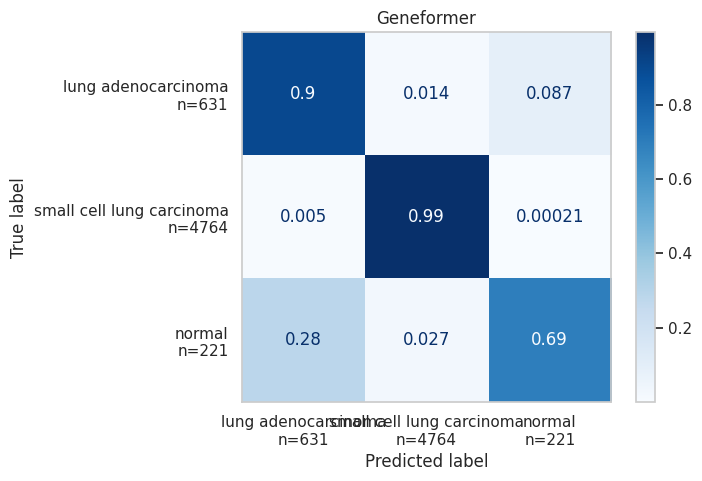

In [92]:
cc.plot_conf_mat(
    conf_mat_dict={"Geneformer": all_metrics_test["conf_matrix"]},
    output_directory="finetuned_model3",
    output_prefix="lung_classifier3",
    custom_class_order=["lung adenocarcinoma", "small cell lung carcinoma", "normal"]
)

<Figure size 1500x1500 with 0 Axes>

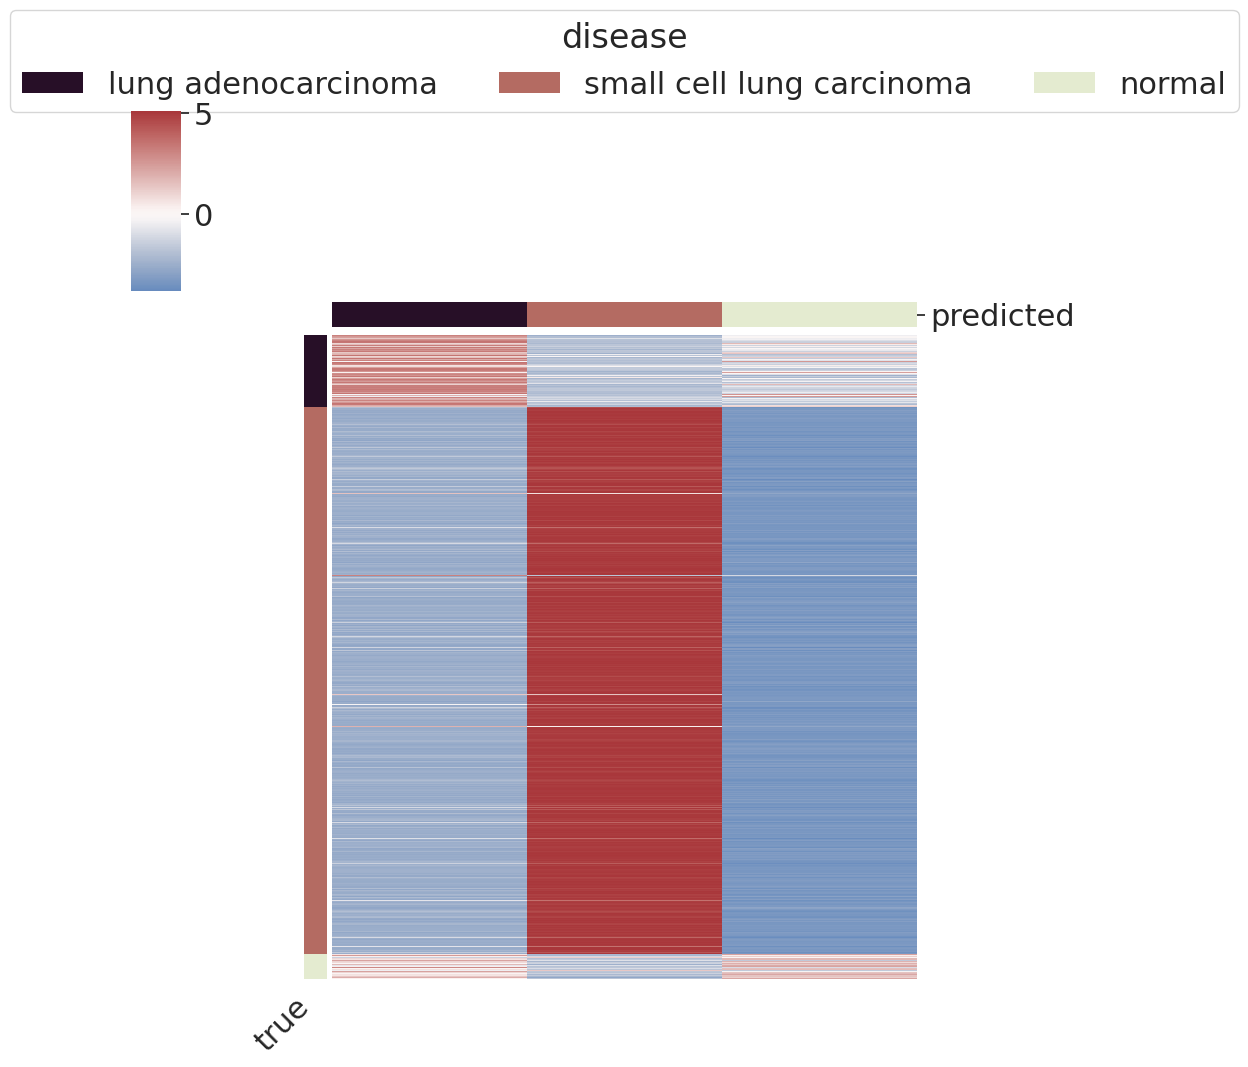

In [94]:
cc.plot_predictions(
    predictions_file="finetuned_model3/lung_classifier3_pred_dict.pkl",
    id_class_dict_file="finetuned_model3/lung_classifier3_id_class_dict.pkl",
    title="disease",
    output_directory="finetuned_model3",
    output_prefix="lung_classifier3",
    custom_class_order=["lung adenocarcinoma", "small cell lung carcinoma", "normal"]
)

# Get embedding

In [99]:
from geneformer import EmbExtractor
embex = EmbExtractor(
    model_type="CellClassifier",
    num_classes=2,
    filter_data=None,
    max_ncells=None,
    emb_layer=-1,
    emb_label=["disease", "individual"],
    labels_to_plot=["disease", "individual"],
    forward_batch_size=256,
    nproc=4,
    model_version="V1",
)

embs = embex.extract_embs(
    model_directory="finetuned_model/260611_geneformer_cellClassifier_cm_dz_classifier/ksplit1/",
    input_data_file="output_data/cm_tokenized.dataset",
    output_directory="embed_data",
    output_prefix="finetuned_embs"
)

print(type(embs))
try:
    print(embs.shape)
except Exception:
    pass

model_version selected as V1 so changing emb_mode from 'cls' to 'cell' as V1 models do not have a <cls> token.
100%|█████████████████████████████████████████| 123/123 [02:16<00:00,  1.11s/it]


<class 'pandas.core.frame.DataFrame'>
(31258, 258)


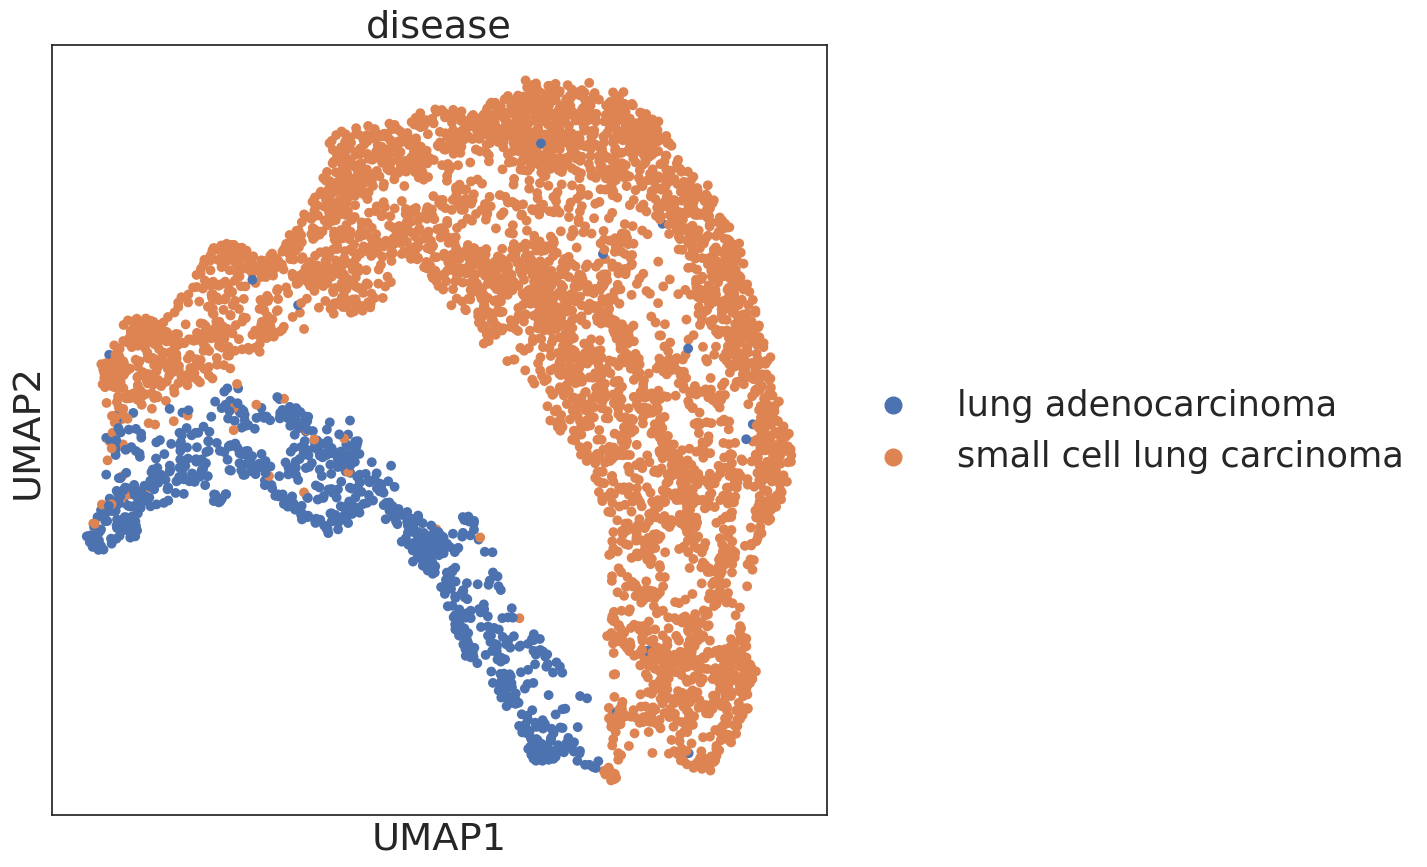

<Figure size 1000x1000 with 0 Axes>

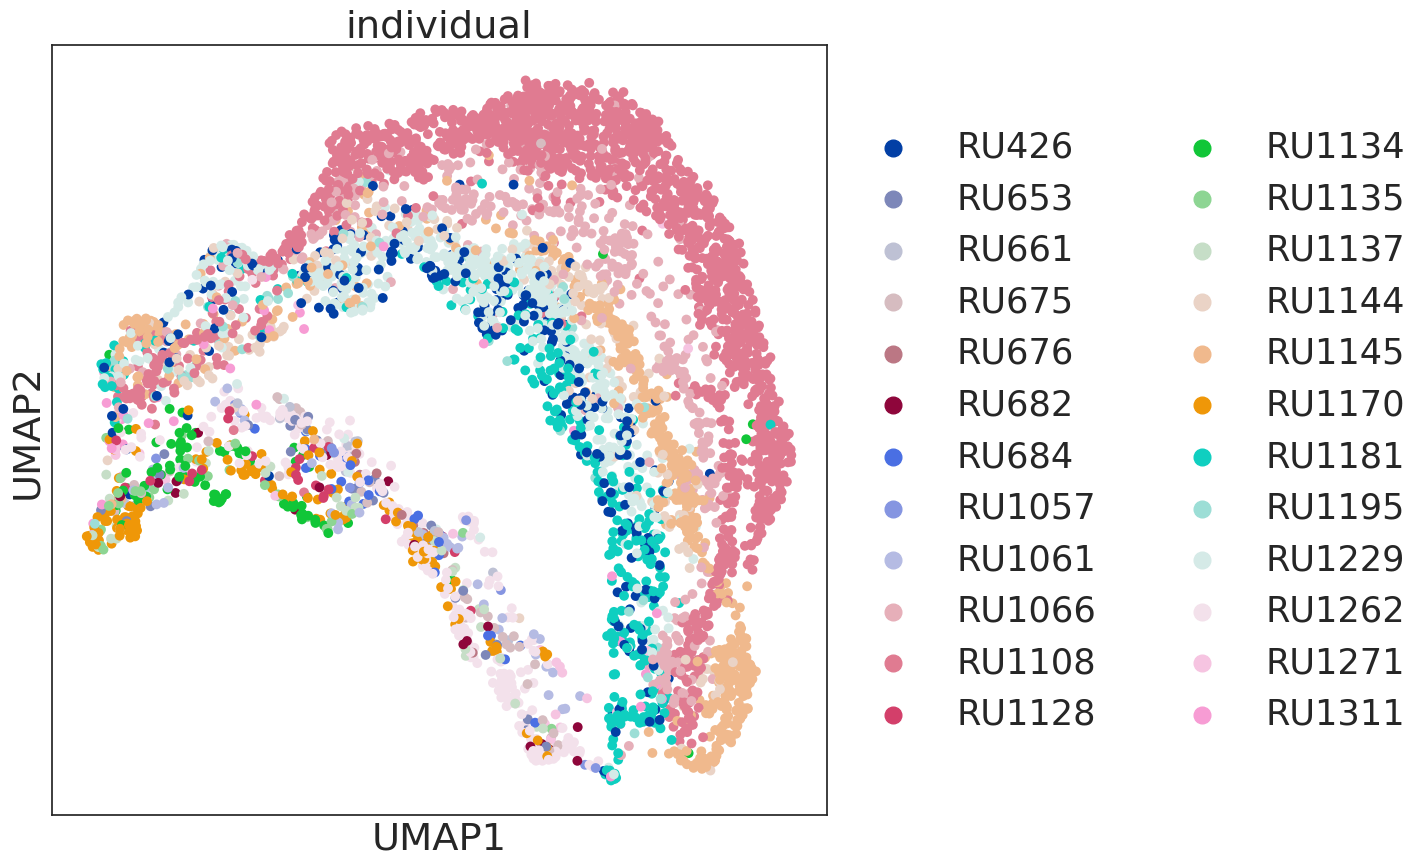

/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1000x1000 with 0 Axes>

<Figure size 2250x2250 with 0 Axes>

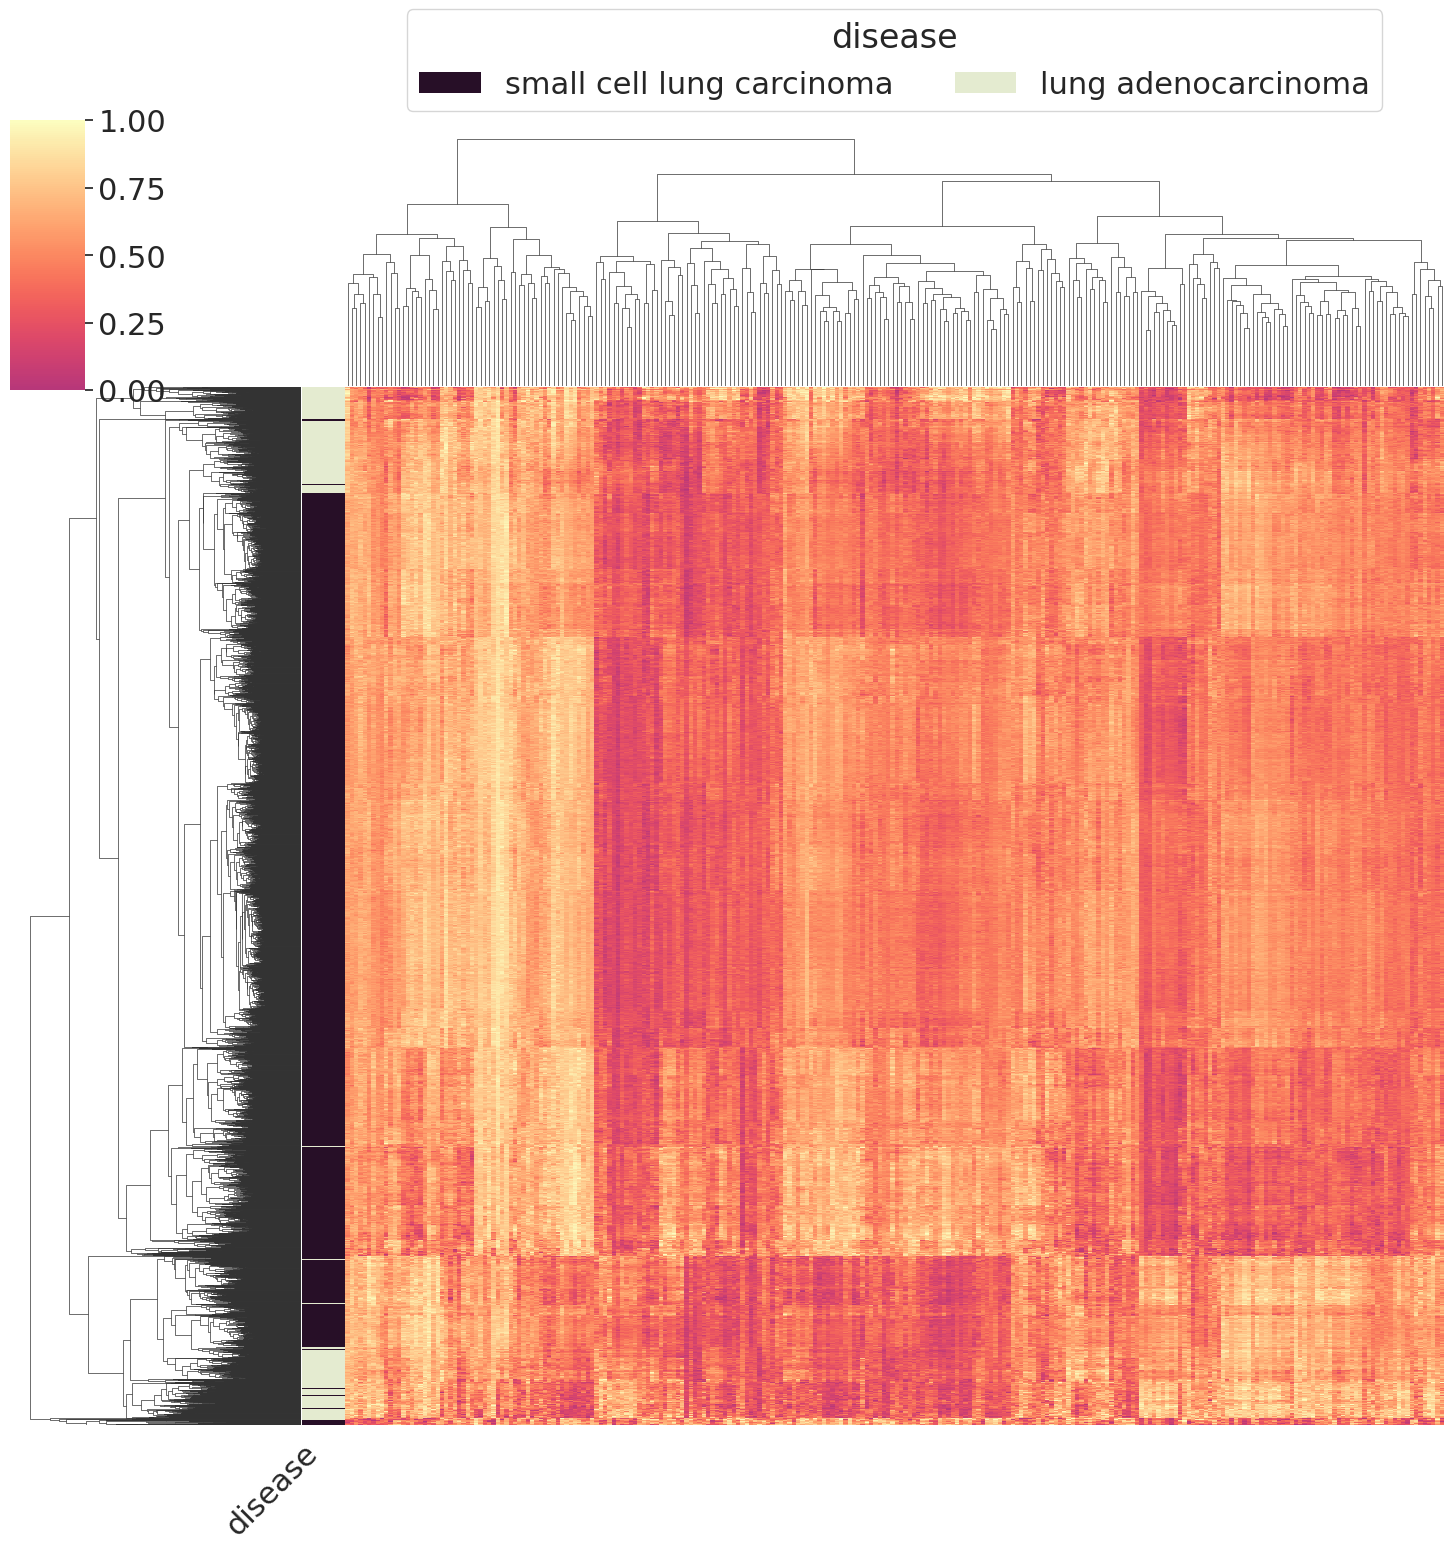

/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1000x1000 with 0 Axes>

<Figure size 2250x2250 with 0 Axes>

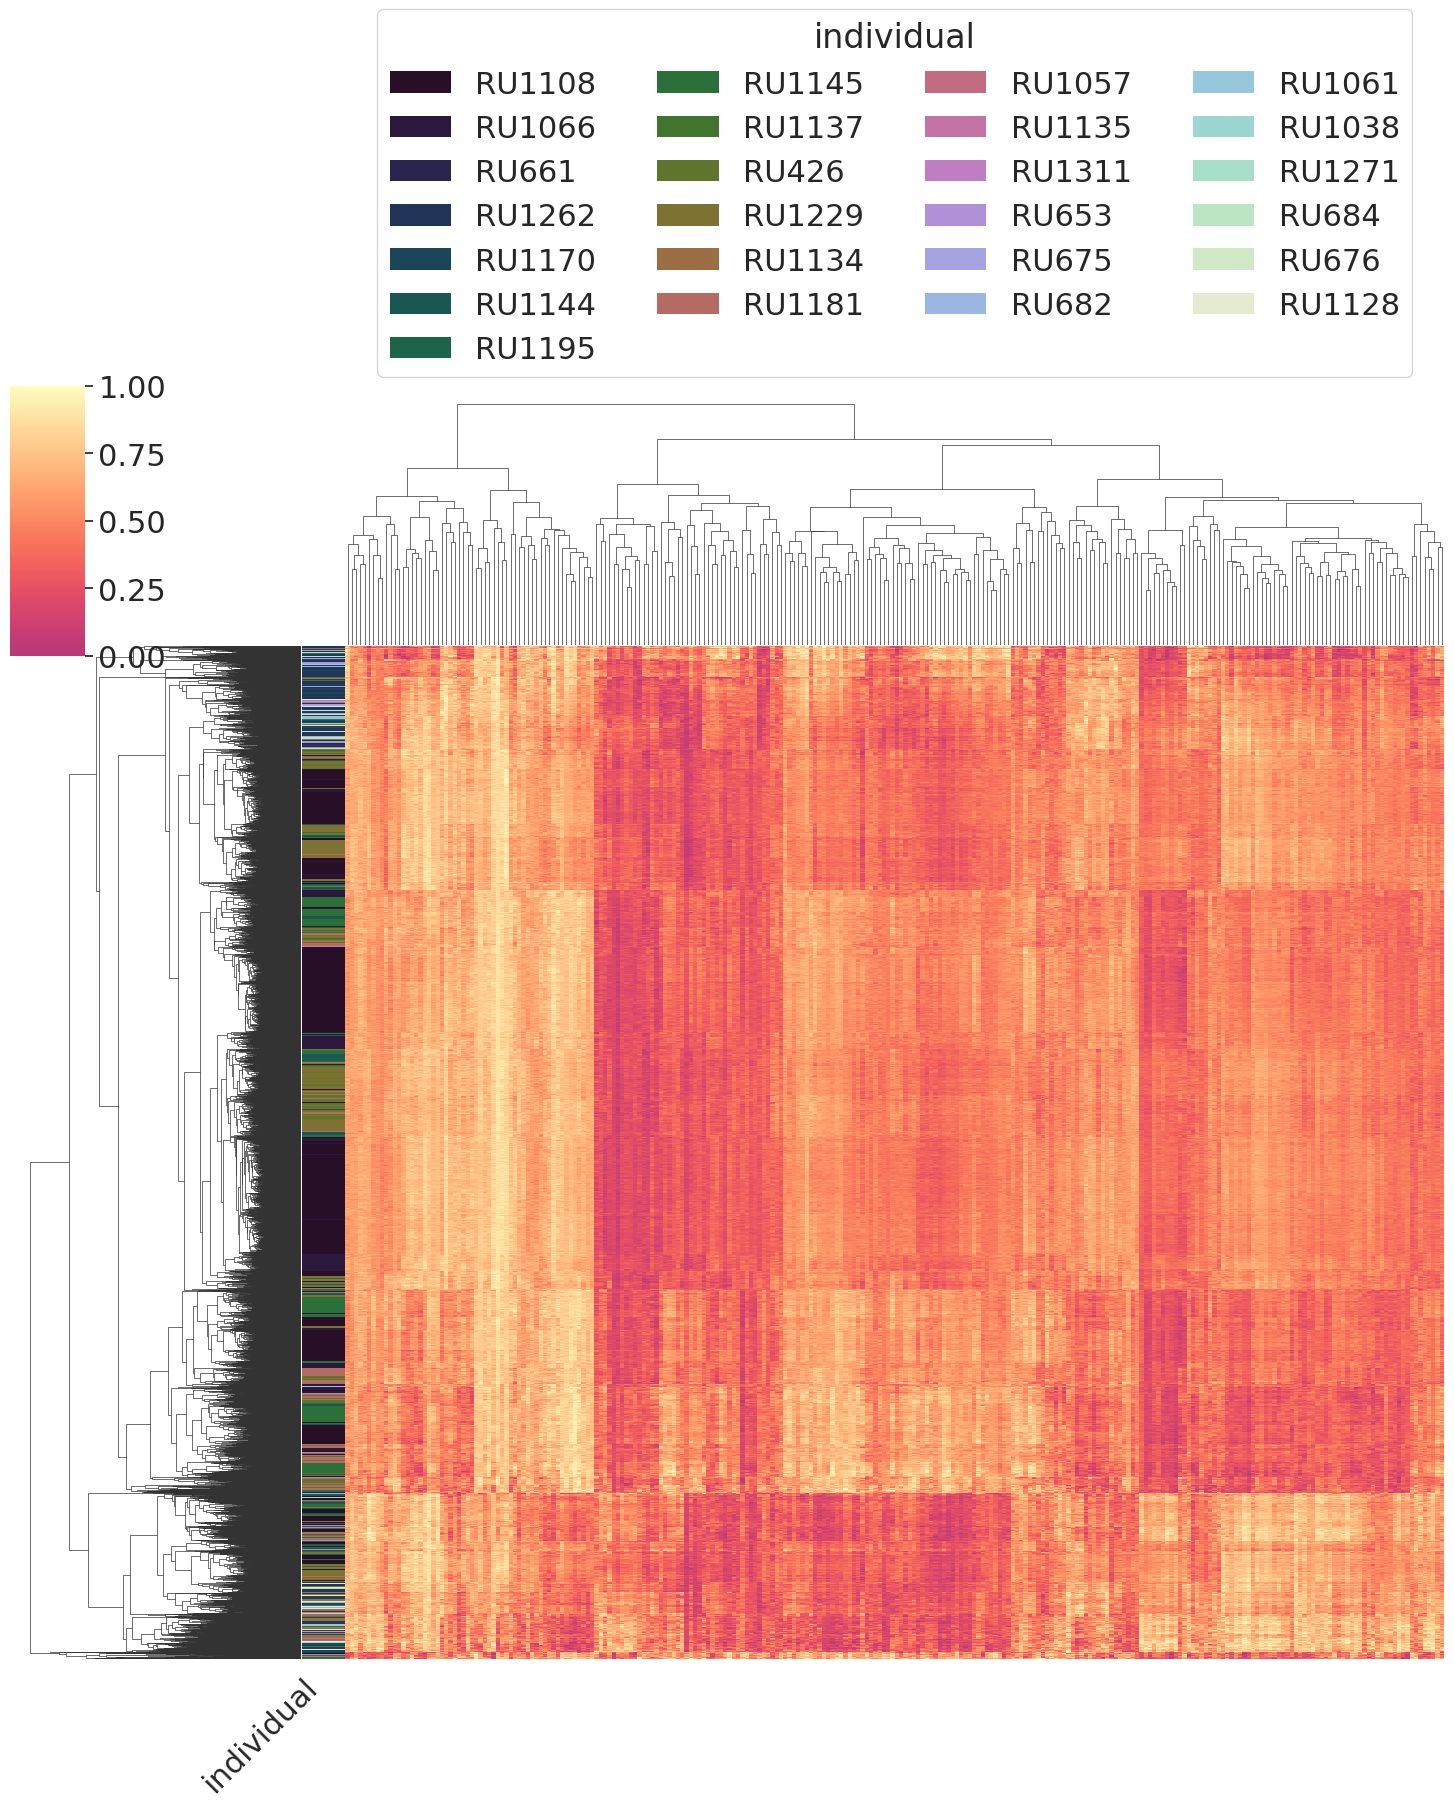

<Figure size 1000x1000 with 0 Axes>

In [100]:
embex.plot_embs(
    embs=embs,
    plot_style="umap",
    output_directory="embed_data",
    output_prefix="emb_umap",
    max_ncells_to_plot=5000,
)

embex.plot_embs(
    embs=embs,
    plot_style="heatmap",
    output_directory="embed_data",
    output_prefix="emb_heatmap",
    max_ncells_to_plot=5000,
)

# pertubation

In [105]:
cell_states_to_model = {
    "state_key": "disease",
    "start_state": "lung adenocarcinoma",
    "goal_state": "small cell lung carcinoma",
    "alt_states": [],
}

embex = EmbExtractor(
    model_type="CellClassifier",
    num_classes=2,
    filter_data=None,
    max_ncells=5000,
    emb_layer=-1,
    summary_stat="exact_mean",
    # emb_label=["disease", "individual"],
    # labels_to_plot=["disease", "individual"],
    forward_batch_size=256,
    nproc=4,
    model_version="V1",
)

state_embs_dict = embex.get_state_embs(
    cell_states_to_model,
    model_directory="finetuned_model/260611_geneformer_cellClassifier_cm_dz_classifier/ksplit1/",
    input_data_file="output_data/cm_tokenized.dataset",
    output_directory="embed_data",
    output_prefix="state_embs",
)

state_embs_dict.keys()

model_version selected as V1 so changing emb_mode from 'cls' to 'cell' as V1 models do not have a <cls> token.
100%|███████████████████████████████████████████| 20/20 [00:23<00:00,  1.16s/it]


dict_keys(['lung adenocarcinoma', 'small cell lung carcinoma'])

In [ ]:
from geneformer import InSilicoPerturber

perturbation_type = "overexpress"
genes_to_perturb = "all"

isp = InSilicoPerturber(
    perturb_type=perturbation_type,
    genes_to_perturb=genes_to_perturb,
    model_type="CellClassifier",
    num_classes=2,
    emb_mode="cell",
    cell_states_to_model=cell_states_to_model,
    state_embs_dict=state_embs_dict,
    max_ncells=2500,
    emb_layer=-1,
    forward_batch_size=256,
    nproc=4,
    model_version="V1",
)

isp.perturb_data(
    model_directory="finetuned_model/260611_geneformer_cellClassifier_cm_dz_classifier/ksplit1/",
    input_data_file="output_data/cm_tokenized.dataset",
    output_directory="pert_overexpress",
    output_prefix="overexpress_to_sclc",
)

In [108]:
from geneformer import InSilicoPerturberStats
ispstats = InSilicoPerturberStats(
    mode="goal_state_shift",
    genes_perturbed="all",
    combos=0,
    anchor_gene=None,
    cell_states_to_model=cell_states_to_model,
    model_version="V1",
)

ispstats.get_stats(
    "pert_overexpress",
    None,
    "pert_overexpress_result",
    "isd",
)

  0%|                                                 | 0/15531 [00:00<?, ?it/s]/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/geneformer/in_silico_perturber_stats.py:436: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cos_sims_full_df = pd.concat([cos_sims_full_df, cos_sims_df_i])
100%|█████████████████████████████████████| 15531/15531 [03:27<00:00, 74.86it/s]


In [109]:
results = pd.read_csv("pert_overexpress_result/isd.csv", index_col=0)
results

,Gene,Gene_name,Ensembl_ID,Shift_to_goal_end,Goal_end_vs_random_pval,Goal_end_FDR,N_Detections,Sig
6394,7260,BLK,ENSG00000136573,0.005634,3.816868e-03,4.931721e-02,8,1
3321,3698,NCAPG,ENSG00000109805,0.002922,1.140875e-03,2.079687e-02,9,1
10583,12286,SFTPC,ENSG00000168484,0.002848,1.175188e-31,2.027983e-28,588,1
15360,23875,CCL5,ENSG00000271503,0.002511,2.724857e-10,5.224661e-08,85,1
5884,6681,TPT1,ENSG00000133112,0.002369,3.866017e-78,1.200862e-74,1207,1
...,...,...,...,...,...,...,...,...
7703,8794,TAAR6,ENSG00000146383,-0.014458,8.452721e-02,3.358384e-01,1,0
8845,10175,CD1E,ENSG00000158488,-0.014668,8.452097e-02,3.358384e-01,1,0
12855,15478,FLRT2,ENSG00000185070,-0.015861,8.443985e-02,3.356630e-01,1,0
9781,11307,IL31RA,ENSG00000164509,-0.018636,1.564017e-01,4.504941e-01,2,0


/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


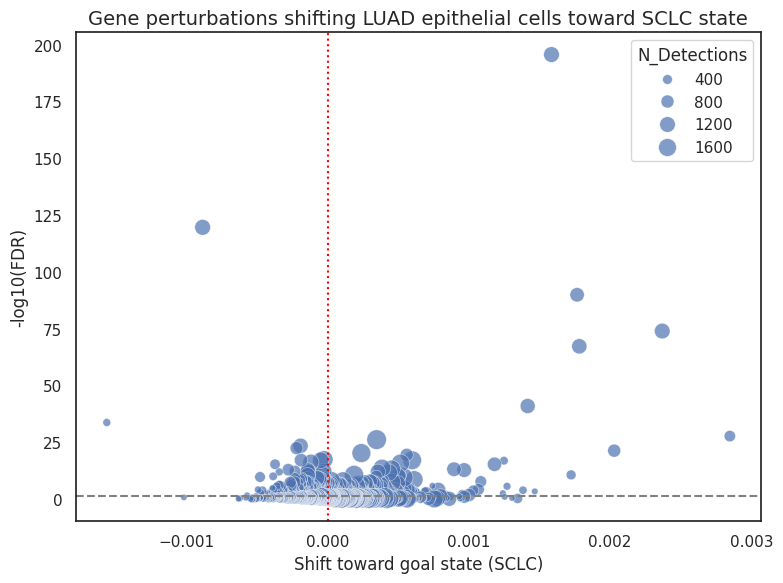

In [112]:
df = results.copy()
df = df[df["N_Detections"] > 100]
df["minus_log10_fdr"] = -np.log10(df["Goal_end_FDR"])

plt.figure(figsize=(8,6))
sns.set_theme(style="white")

sns.scatterplot(data=df,
                x="Shift_to_goal_end", y="minus_log10_fdr", size="N_Detections",
                sizes=(20,200), alpha=0.7
               )
plt.axvline(0, color="red", linestyle=":")
plt.axhline(-np.log10(0.05), color="gray", linestyle="--")

plt.title("Gene perturbations shifting LUAD epithelial cells toward SCLC state", fontsize=14)
plt.xlabel("Shift toward goal state (SCLC)", fontsize=12)
plt.ylabel("-log10(FDR)", fontsize=12)

plt.tight_layout()
plt.show()

        Gene Gene_name       Ensembl_ID  Shift_to_goal_end  \
10583  12286     SFTPC  ENSG00000168484           0.002848   
5884    6681      TPT1  ENSG00000133112           0.002369   
4824    5433      SLPI  ENSG00000124107           0.002029   
13193  15993      PTMA  ENSG00000187514           0.001782   
1185    1319      ACTB  ENSG00000075624           0.001767   
...      ...       ...              ...                ...   
2884    3197     ITGB8  ENSG00000105855          -0.000506   
13338  16229  RALGAPA2  ENSG00000188559          -0.000570   
10489  12172      FTH1  ENSG00000167996          -0.000884   
9438   10887    S100A9  ENSG00000163220          -0.001563   
10218  11842       B2M  ENSG00000166710          -0.003171   

       Goal_end_vs_random_pval   Goal_end_FDR  N_Detections  Sig  
10583             1.175188e-31   2.027983e-28           588    1  
5884              3.866017e-78   1.200862e-74          1207    1  
4824              4.700009e-25   5.213989e-22         

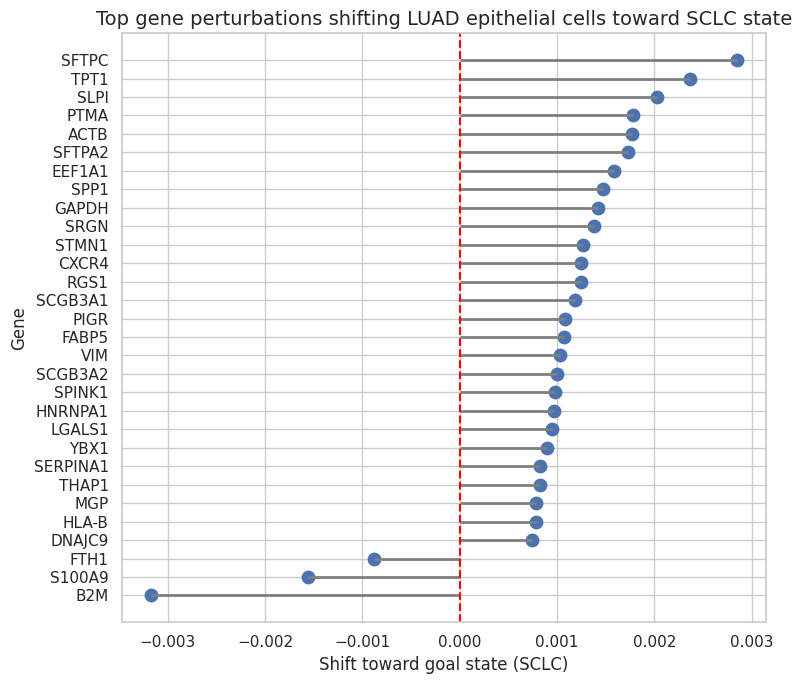

In [113]:
df = results.copy()
df = df[df["Goal_end_FDR"] < 0.05]
df = df[df["N_Detections"] > 100]
print(df)

n_top_genes = 30
df_plot = (
    df.reindex(
        df["Shift_to_goal_end"]
        .abs()
        .sort_values(ascending=False)
        .index
    )
    .head(n_top_genes)
    .sort_values("Shift_to_goal_end")
)

plt.figure(figsize=(8, 7))
sns.set_theme(style="whitegrid")

plt.scatter(df_plot["Shift_to_goal_end"],
            df_plot["Gene_name"],
            s=80
           )
plt.hlines(y=df_plot["Gene_name"], xmin=0, xmax=df_plot["Shift_to_goal_end"], color="gray", linewidth=2)
plt.axvline(x=0, color="red", linestyle="--", linewidth=1.5)

plt.title("Top gene perturbations shifting LUAD epithelial cells toward SCLC state", fontsize=14)
plt.xlabel("Shift toward goal state (SCLC)", fontsize=12)
plt.ylabel("Gene", fontsize=12)

plt.tight_layout()
plt.show()